# CiteSeer Graph Neural Networks
Set up the CiteSeer citation network dataset and define baseline GNN models using the custom layers in `models.py`.

## Imports
Bring in PyTorch, PyG utilities, and the built-in GCN and GraphSAGE models from PyTorch Geometric.

In [1]:
import os
import random
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import add_self_loops, to_dense_adj
from torch_geometric.explain import Explainer, ModelConfig, GNNExplainer, PGExplainer
from torch_geometric.nn.models import GCN, GraphSAGE
from captum.attr import IntegratedGradients as CaptumIG
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
import networkx as nx
from typing import List, Optional
import pandas as pd

/Users/hehvince/Desktop/FYP/FYP_Interpretable_Explanations/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 67

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)

seed_everything(SEED)
print(f"Global random seed set to {SEED}")

Global random seed set to 67


## Dataset Preparation
Load the CiteSeer citation network, move data to the chosen device, and build dense adjacency/features for the custom layer interface.
CiteSeer is a scientific publication dataset with 6 classes representing different research topics.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = Planetoid(root="./data/Planetoid", name="CiteSeer")
data = dataset[0].to(device)

# Prepare edge index with self-loops plus convenience tensors
edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
data.edge_index = edge_index
adjacency = to_dense_adj(edge_index, max_num_nodes=data.num_nodes)[0].to(device)
features = data.x.to(device)
labels = data.y.to(device)

in_feats = features.size(-1)
num_classes = dataset.num_classes

# Provide a dummy batch vector so pooled models operate on the single graph
data.batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

# CiteSeer has 6 classes representing different research topics
citeseer_class_names = [
    "Agents",
    "AI",
    "DB",
    "IR",
    "ML",
    "HCI",
]
label_ids = sorted(labels.cpu().unique().tolist())
label_name_map = {idx: citeseer_class_names[idx] for idx in label_ids}

# CiteSeer comes with predefined train/val/test masks
train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask

print(dataset)
print(f"Feature matrix: {features.shape}, adjacency: {adjacency.shape}")
print(f"Nodes: {data.num_nodes}, Features per node: {dataset.num_features}, Classes: {dataset.num_classes}")
print("Unique class labels:", label_name_map)
print(f"Train nodes: {train_mask.sum().item()}, Val nodes: {val_mask.sum().item()}, Test nodes: {test_mask.sum().item()}")

CiteSeer()
Feature matrix: torch.Size([3327, 3703]), adjacency: torch.Size([3327, 3327])
Nodes: 3327, Features per node: 3703, Classes: 6
Unique class labels: {0: 'Agents', 1: 'AI', 2: 'DB', 3: 'IR', 4: 'ML', 5: 'HCI'}
Train nodes: 120, Val nodes: 500, Test nodes: 1000


## Instantiate and Inspect Models
Create GCN and GraphSAGE models using PyTorch Geometric's built-in implementations, run dry forwards, and confirm output dimensions.

In [4]:
gcn_model = GCN(
    in_channels=dataset.num_features,
    hidden_channels=64,
    num_layers=2,
    out_channels=dataset.num_classes,
    dropout=0.5
).to(device)

graphsage_model = GraphSAGE(
    in_channels=dataset.num_features,
    hidden_channels=64,
    num_layers=2,
    out_channels=dataset.num_classes,
    dropout=0.5
).to(device)

gcn_model.eval()
graphsage_model.eval()

with torch.no_grad():
    gcn_logits = gcn_model(data.x, data.edge_index)
    graphsage_logits = graphsage_model(data.x, data.edge_index)

print(f"GCN output shape: {gcn_logits.shape}")
print(f"GraphSAGE output shape: {graphsage_logits.shape}")

GCN output shape: torch.Size([3327, 6])
GraphSAGE output shape: torch.Size([3327, 6])


## Embedding Visualisation Helpers
Project model outputs into 2D via t-SNE for before/after comparisons.

In [5]:
def tsne_project(tensor: torch.Tensor, perplexity: float = 30.0, random_state: int = 42) -> torch.Tensor:
    embedding_np = tensor.detach().cpu().numpy()
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    coords = tsne.fit_transform(embedding_np)
    return torch.from_numpy(coords).float()

def plot_embeddings(coords_gcn, coords_sage, title_suffix: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    labels_cpu = labels.cpu()
    for ax, coords, model_name in zip(
        axes,
        (coords_gcn, coords_sage),
        ("GCN", "GraphSAGE"),
    ):
        ax.scatter(
            coords[:, 0],
            coords[:, 1],
            c=labels_cpu,
            cmap="tab10",
            s=10,
            alpha=0.8,
        )
        ax.set_title(f"{model_name} {title_suffix}")
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
    cmap = plt.cm.get_cmap("tab10", len(label_name_map))
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap(class_id), markersize=6)
        for class_id in sorted(label_name_map)
    ]
    axes[-1].legend(
        handles,
        [label_name_map[idx] for idx in sorted(label_name_map)],
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )
    plt.tight_layout()
    plt.show()

## Pre-Training Embedding Snapshot
Visualise random-initialised model outputs with t-SNE before any optimisation.

/var/folders/cx/t80f8k7j2h1b0cnx64j7nxg00000gn/T/ipykernel_70115/2766157793.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(label_name_map))


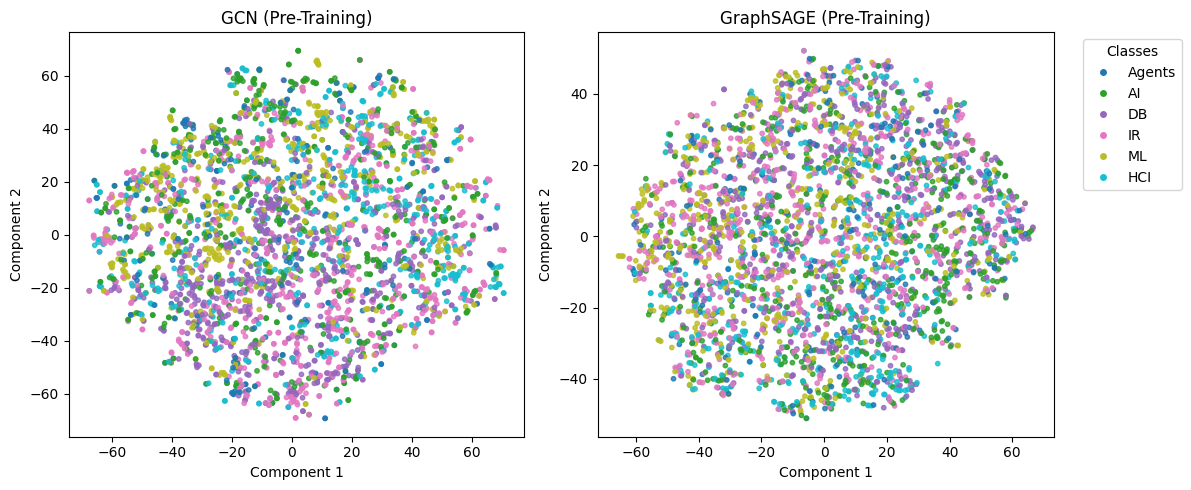

In [6]:
with torch.no_grad():
    gcn_model.eval()
    graphsage_model.eval()
    pre_gcn_logits = gcn_model(data.x, data.edge_index)
    pre_sage_logits = graphsage_model(data.x, data.edge_index)

pre_gcn_coords = tsne_project(pre_gcn_logits)
pre_sage_coords = tsne_project(pre_sage_logits)
plot_embeddings(pre_gcn_coords, pre_sage_coords, "(Pre-Training)")

## Training Utilities
Set up loss functions, optimizers, and helper routines to train and evaluate both models.

In [7]:
loss_fn = nn.CrossEntropyLoss()

train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask

# Balanced setup: less aggressive regularization to reduce underfitting
gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.005, weight_decay=5e-3)
graphsage_optimizer = torch.optim.Adam(graphsage_model.parameters(), lr=0.005, weight_decay=5e-4)

gcn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    gcn_optimizer, mode="min", factor=0.7, patience=30, min_lr=3e-4
)
sage_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    graphsage_optimizer, mode="min", factor=0.7, patience=30, min_lr=3e-4
)

def train_gcn() -> tuple[float, float]:
    gcn_model.train()
    gcn_optimizer.zero_grad()
    logits = gcn_model(data.x, data.edge_index)
    loss = loss_fn(logits[train_mask], labels[train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gcn_model.parameters(), max_norm=2.0)
    gcn_optimizer.step()
    preds = logits.argmax(dim=-1)
    train_acc = (preds[train_mask] == labels[train_mask]).float().mean().item()
    return loss.item(), train_acc

def train_graphsage() -> tuple[float, float]:
    graphsage_model.train()
    graphsage_optimizer.zero_grad()
    logits = graphsage_model(data.x, data.edge_index)
    loss = loss_fn(logits[train_mask], labels[train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(graphsage_model.parameters(), max_norm=2.0)
    graphsage_optimizer.step()
    preds = logits.argmax(dim=-1)
    train_acc = (preds[train_mask] == labels[train_mask]).float().mean().item()
    return loss.item(), train_acc

@torch.no_grad()
def evaluate_gcn(mask: torch.Tensor):
    gcn_model.eval()
    logits = gcn_model(data.x, data.edge_index)
    preds = logits.argmax(dim=-1)
    loss = loss_fn(logits[mask], labels[mask])
    acc = (preds[mask] == labels[mask]).float().mean().item()
    return loss.item(), acc, preds

@torch.no_grad()
def evaluate_graphsage(mask: torch.Tensor):
    graphsage_model.eval()
    logits = graphsage_model(data.x, data.edge_index)
    preds = logits.argmax(dim=-1)
    loss = loss_fn(logits[mask], labels[mask])
    acc = (preds[mask] == labels[mask]).float().mean().item()
    return loss.item(), acc, preds

## Train Models
Run a joint training loop and monitor validation loss/accuracy for both architectures.

In [8]:
# Early stopping + best-checkpoint restore + LR scheduling for both models
gcn_epochs = 1000
best_val_loss = float("inf")
patience = 100
patience_counter = 0
best_gcn_state = None

for epoch in range(1, gcn_epochs + 1):
    gcn_loss, gcn_train_acc = train_gcn()
    gcn_val_loss, gcn_val_acc, _ = evaluate_gcn(val_mask)
    gcn_scheduler.step(gcn_val_loss)

    if gcn_val_loss < best_val_loss:
        best_val_loss = gcn_val_loss
        patience_counter = 0
        best_gcn_state = {k: v.detach().cpu().clone() for k, v in gcn_model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 20 == 0 or epoch == gcn_epochs:
        current_lr = gcn_optimizer.param_groups[0]["lr"]
        print(
            f"[GCN] Epoch {epoch:03d} | "
            f"train {gcn_loss:.4f} (acc {gcn_train_acc:.4f}) / "
            f"val {gcn_val_loss:.4f} (acc {gcn_val_acc:.4f}) | "
            f"best_val {best_val_loss:.4f} | lr {current_lr:.6f}"
        )

    if patience_counter >= patience:
        print(f"[GCN] Early stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})")
        break

if best_gcn_state is not None:
    gcn_model.load_state_dict(best_gcn_state)

graphsage_epochs = 1000
best_sage_val_loss = float("inf")
sage_patience = 100
sage_patience_counter = 0
best_sage_state = None

for epoch in range(1, graphsage_epochs + 1):
    sage_loss, sage_train_acc = train_graphsage()
    sage_val_loss, sage_val_acc, _ = evaluate_graphsage(val_mask)
    sage_scheduler.step(sage_val_loss)

    if sage_val_loss < best_sage_val_loss:
        best_sage_val_loss = sage_val_loss
        sage_patience_counter = 0
        best_sage_state = {k: v.detach().cpu().clone() for k, v in graphsage_model.state_dict().items()}
    else:
        sage_patience_counter += 1

    if epoch == 1 or epoch % 20 == 0 or epoch == graphsage_epochs:
        current_lr = graphsage_optimizer.param_groups[0]["lr"]
        print(
            f"[GraphSAGE] Epoch {epoch:03d} | "
            f"train {sage_loss:.4f} (acc {sage_train_acc:.4f}) / "
            f"val {sage_val_loss:.4f} (acc {sage_val_acc:.4f}) | "
            f"best_val {best_sage_val_loss:.4f} | lr {current_lr:.6f}"
        )

    if sage_patience_counter >= sage_patience:
        print(f"[GraphSAGE] Early stopping at epoch {epoch} (best val loss: {best_sage_val_loss:.4f})")
        break

if best_sage_state is not None:
    graphsage_model.load_state_dict(best_sage_state)

print(f"Loaded best checkpoints -> GCN best val loss: {best_val_loss:.4f}, GraphSAGE best val loss: {best_sage_val_loss:.4f}")

[GCN] Epoch 001 | train 1.7865 (acc 0.2000) / val 1.7195 (acc 0.5420) | best_val 1.7195 | lr 0.005000
[GCN] Epoch 020 | train 0.0963 (acc 1.0000) / val 0.9799 (acc 0.6920) | best_val 0.9799 | lr 0.005000
[GCN] Epoch 040 | train 0.0875 (acc 1.0000) / val 0.9616 (acc 0.6960) | best_val 0.9497 | lr 0.005000
[GCN] Epoch 060 | train 0.0766 (acc 1.0000) / val 0.9439 (acc 0.7040) | best_val 0.9431 | lr 0.005000
[GCN] Epoch 080 | train 0.0684 (acc 1.0000) / val 0.9458 (acc 0.7000) | best_val 0.9370 | lr 0.005000
[GCN] Epoch 100 | train 0.0627 (acc 1.0000) / val 0.9549 (acc 0.6920) | best_val 0.9298 | lr 0.005000
[GCN] Epoch 120 | train 0.0542 (acc 1.0000) / val 0.9296 (acc 0.7020) | best_val 0.9284 | lr 0.005000
[GCN] Epoch 140 | train 0.0613 (acc 1.0000) / val 0.9525 (acc 0.6960) | best_val 0.9260 | lr 0.005000
[GCN] Epoch 160 | train 0.0544 (acc 1.0000) / val 0.9419 (acc 0.6920) | best_val 0.9260 | lr 0.003500
[GCN] Epoch 180 | train 0.0532 (acc 1.0000) / val 0.9314 (acc 0.6980) | best_val 0

## Evaluate on Test Set
Measure final performance and compare a handful of predicted labels against the ground truth.

In [9]:
gcn_test_loss, gcn_test_acc, gcn_preds = evaluate_gcn(test_mask)
sage_test_loss, sage_test_acc, sage_preds = evaluate_graphsage(test_mask)

print(f"GCN test loss {gcn_test_loss:.4f}, accuracy {gcn_test_acc:.4f}")
print(f"GraphSAGE test loss {sage_test_loss:.4f}, accuracy {sage_test_acc:.4f}")

test_indices = test_mask.nonzero(as_tuple=False).view(-1)
sample_count = min(10, test_indices.numel())
sample_indices = test_indices[:sample_count]

if sample_count == 0:
    print("No test nodes available in the current split.")
else:
    print("\nSample predictions on test nodes:")
    for idx in sample_indices:
        idx_int = int(idx.item())
        true_label = int(labels[idx].item())
        gcn_label = int(gcn_preds[idx].item())
        sage_label = int(sage_preds[idx].item())
        print(
            f"Node {idx_int:4d} | True: {true_label} | "
            f"GCN: {gcn_label} | GraphSAGE: {sage_label}"
        )

GCN test loss 0.9067, accuracy 0.7050
GraphSAGE test loss 0.9948, accuracy 0.6800

Sample predictions on test nodes:
Node 2312 | True: 4 | GCN: 4 | GraphSAGE: 4
Node 2313 | True: 5 | GCN: 2 | GraphSAGE: 4
Node 2314 | True: 4 | GCN: 4 | GraphSAGE: 4
Node 2315 | True: 4 | GCN: 4 | GraphSAGE: 4
Node 2316 | True: 4 | GCN: 4 | GraphSAGE: 4
Node 2317 | True: 1 | GCN: 0 | GraphSAGE: 0
Node 2318 | True: 4 | GCN: 4 | GraphSAGE: 4
Node 2319 | True: 2 | GCN: 2 | GraphSAGE: 2
Node 2320 | True: 3 | GCN: 3 | GraphSAGE: 3
Node 2321 | True: 3 | GCN: 3 | GraphSAGE: 3


## GNN Explainer Interpretability
Use GNN Explainer to visualise influential subgraphs for sample predictions and quantify explanation quality.

In [10]:
EXPLAINER_PARAMS_V2 = {
    'gnn_explainer_epochs': 350,
    'gnn_stability_epochs': 240,
    'pg_explainer_epochs': 40,
    'pg_lr': 0.0025,
    'pg_train_sample_size': 140,
    'ig_n_steps': 192,
    'ig_internal_batch_size': 1,
    'stability_runs': 9,
    'edge_selection_quantile': 0.94,
    'edge_selection_min_edges': 12,
}
print('Using explainer parameters from mainCorav4 (tuned_v4):', EXPLAINER_PARAMS_V2)

def _normalize_node_mask(node_mask, x: torch.Tensor, node_idx: int) -> torch.Tensor:
    if node_mask is None:
        return torch.ones_like(x)
    if node_mask.dim() == 2:
        if node_mask.shape == x.shape:
            return node_mask
        if node_mask.size(0) == x.size(0) and node_mask.size(1) == 1:
            return node_mask.repeat(1, x.size(-1))
    if node_mask.dim() == 1:
        if node_mask.numel() == x.size(-1):
            expanded = torch.ones_like(x)
            expanded[node_idx] = node_mask
            return expanded
        if node_mask.numel() == x.size(0):
            return node_mask.unsqueeze(-1).repeat(1, x.size(-1))
    if node_mask.dim() == 2 and node_mask.size(1) == x.size(-1):
        return node_mask
    return torch.ones_like(x)

def _build_target_tensor(node_idx: int, data, labels: torch.Tensor, model: torch.nn.Module) -> tuple[torch.Tensor, int]:
    """Build target tensor based on model's actual prediction, not ground truth."""
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        predicted_class = int(logits[node_idx].argmax().item())
    target_tensor = torch.full((data.num_nodes,), predicted_class, dtype=labels.dtype, device=labels.device)
    return target_tensor, predicted_class

def _prepare_edge_subset(
    edge_index: torch.Tensor,
    edge_mask: torch.Tensor,
    selection: torch.Tensor,
    max_edges: Optional[int] = None,
    inverse: bool = False,
 ) -> tuple[torch.Tensor, torch.Tensor]:
    """Prepare edge subset based on selection. If inverse=True, selects edges NOT in selection."""
    if inverse:
        selected_idx = (~selection).nonzero(as_tuple=False).view(-1)
    else:
        selected_idx = selection.nonzero(as_tuple=False).view(-1)
    if selected_idx.numel() == 0:
        selected_idx = edge_mask.topk(1).indices
    if max_edges is not None and selected_idx.numel() > max_edges:
        mask_values = edge_mask[selected_idx]
        topk = mask_values.topk(max_edges).indices
        selected_idx = selected_idx[topk]
    sub_edge_index = edge_index[:, selected_idx]
    sub_edge_mask = edge_mask[selected_idx]
    return sub_edge_index, sub_edge_mask

def _plot_explanation(
    node_idx: int,
    edge_index: torch.Tensor,
    edge_mask: torch.Tensor,
    selection: torch.Tensor,
    ax: plt.Axes,
    max_edges: Optional[int] = 20,
):
    sub_edge_index, sub_edge_mask = _prepare_edge_subset(
        edge_index, edge_mask, selection, max_edges=max_edges, inverse=False
    )
    sub_edge_index = sub_edge_index.detach().cpu()
    sub_edge_mask = sub_edge_mask.detach().cpu()
    graph = nx.Graph()
    edges = sub_edge_index.t().tolist()
    weights = sub_edge_mask.tolist() if sub_edge_mask.numel() > 0 else []
    nodes = set()
    for idx, (src, dst) in enumerate(edges):
        weight = weights[idx] if idx < len(weights) else 0.0
        graph.add_edge(src, dst, weight=float(weight))
        nodes.add(src)
        nodes.add(dst)
    nodes.add(node_idx)
    graph.add_nodes_from(nodes)
    if node_idx not in graph:
        graph.add_node(node_idx)
    for node in graph.nodes():
        label_val = int(labels[node].item())
        graph.nodes[node]["label"] = label_name_map.get(label_val, str(label_val))
    pos = nx.spring_layout(graph, seed=42)
    node_colors = ["#ff7f0e" if node == node_idx else "#1f77b4" for node in graph.nodes()]
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=300, alpha=0.9, ax=ax)
    if graph.number_of_edges() > 0:
        edge_weights = [max(float(data.get("weight", 0.0)), 0.0) for _, _, data in graph.edges(data=True)]
        w_min = min(edge_weights)
        w_max = max(edge_weights)
        if w_max - w_min < 1e-9:
            norm_vals = [0.5 for _ in edge_weights]
        else:
            norm_vals = [(w - w_min) / (w_max - w_min) for w in edge_weights]
        edge_colors = [plt.cm.Reds(v) for v in norm_vals]
        edge_widths = [1.5 + 2.5 * v for v in norm_vals]
        nx.draw_networkx_edges(graph, pos, edge_color=edge_colors, width=edge_widths, ax=ax)
    nx.draw_networkx_labels(graph, pos, labels={n: graph.nodes[n]["label"] for n in graph.nodes()}, font_size=8, ax=ax)
    ax.set_axis_off()

def run_gnn_explainer(model: torch.nn.Module, node_idx: int, data, epochs: Optional[int] = None):
    model.eval()
    epochs = EXPLAINER_PARAMS_V2["gnn_explainer_epochs"] if epochs is None else epochs
    target_tensor, predicted_class = _build_target_tensor(node_idx, data, labels, model)
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=epochs),
        explanation_type="phenomenon",
        model_config=ModelConfig(
            mode="multiclass_classification",
            task_level="node",
            return_type="raw",
        ),
        node_mask_type="attributes",
        edge_mask_type="object",
    )
    explanation = explainer(data.x, data.edge_index, index=node_idx, target=target_tensor)
    edge_mask = explanation.edge_mask
    if edge_mask is None:
        edge_mask = torch.zeros(data.edge_index.size(1), device=data.edge_index.device)
    node_feat_mask = _normalize_node_mask(explanation.node_mask, data.x, node_idx).to(data.x.device)
    edge_mask = edge_mask.to(data.edge_index.device)
    return explainer, explanation, node_feat_mask, edge_mask, predicted_class

def run_pg_explainer(
    model: torch.nn.Module,
    node_idx: int,
    data,
    epochs: Optional[int] = None,
    lr: Optional[float] = None,
    train_sample_size: Optional[int] = None,
 ):
    """Run PGExplainer - a parameterized explainer that learns to explain."""
    model.eval()
    epochs = EXPLAINER_PARAMS_V2["pg_explainer_epochs"] if epochs is None else epochs
    lr = EXPLAINER_PARAMS_V2["pg_lr"] if lr is None else lr
    train_sample_size = EXPLAINER_PARAMS_V2["pg_train_sample_size"] if train_sample_size is None else train_sample_size
    target_tensor, predicted_class = _build_target_tensor(node_idx, data, labels, model)
    explainer = Explainer(
        model=model,
        algorithm=PGExplainer(epochs=epochs, lr=lr),
        explanation_type="phenomenon",
        model_config=ModelConfig(
            mode="multiclass_classification",
            task_level="node",
            return_type="raw",
        ),
        node_mask_type=None,
        edge_mask_type="object",
    )
    train_indices = data.train_mask.nonzero(as_tuple=False).view(-1)
    import random
    sample_size = min(train_sample_size, train_indices.numel())
    sampled_indices = random.sample(train_indices.tolist(), sample_size)
    for epoch in range(epochs):
        for index in sampled_indices:
            loss = explainer.algorithm.train(
                epoch, model, data.x, data.edge_index, target=target_tensor, index=index
            )
    explanation = explainer(data.x, data.edge_index, index=node_idx, target=target_tensor)
    edge_mask = explanation.edge_mask
    if edge_mask is None:
        edge_mask = torch.zeros(data.edge_index.size(1), device=data.edge_index.device)
    node_feat_mask = torch.ones_like(data.x)
    edge_mask = edge_mask.to(data.edge_index.device)
    return explainer, explanation, node_feat_mask, edge_mask, predicted_class

def _derive_edge_mask_from_node_mask(node_mask: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
    """Derive edge importance from node-level attributions. For each edge (u, v), importance = (node_imp[u] + node_imp[v]) / 2."""
    if node_mask is None:
        return torch.zeros(edge_index.size(1), device=edge_index.device)
    if node_mask.dim() == 2:
        node_imp = node_mask.abs().norm(dim=1)
    else:
        node_imp = node_mask.abs()
    if node_imp.max() > 0:
        node_imp = node_imp / node_imp.max()
    src, dst = edge_index[0], edge_index[1]
    return ((node_imp[src] + node_imp[dst]) / 2.0).detach()

def run_integrated_gradients(model: torch.nn.Module, node_idx: int, data):
    """Run Integrated Gradients using Captum directly (bypassing CaptumExplainer)."""
    model.eval()
    _, predicted_class = _build_target_tensor(node_idx, data, labels, model)
    x = data.x.clone()
    edge_index = data.edge_index
    def forward_func(x_input):
        out = model(x_input.squeeze(0), edge_index)
        return out[node_idx].unsqueeze(0)
    ig = CaptumIG(forward_func)
    attributions = ig.attribute(
        x.unsqueeze(0), target=predicted_class,
        internal_batch_size=EXPLAINER_PARAMS_V2["ig_internal_batch_size"], n_steps=EXPLAINER_PARAMS_V2["ig_n_steps"],
    )
    node_mask = attributions.squeeze(0).detach()
    node_feat_mask = _normalize_node_mask(node_mask, data.x, node_idx).to(dtype=data.x.dtype, device=data.x.device)
    edge_mask = _derive_edge_mask_from_node_mask(node_mask, data.edge_index)
    edge_mask = edge_mask.to(dtype=data.x.dtype, device=data.edge_index.device)
    explanation = {"node_mask": node_mask, "edge_mask": edge_mask, "predicted_class": predicted_class}
    return None, explanation, node_feat_mask, edge_mask, predicted_class

def build_edge_selection(edge_mask: torch.Tensor) -> torch.Tensor:
    if edge_mask.numel() == 0:
        return torch.zeros_like(edge_mask, dtype=torch.bool)
    q = EXPLAINER_PARAMS_V2["edge_selection_quantile"]
    min_edges = min(EXPLAINER_PARAMS_V2["edge_selection_min_edges"], edge_mask.numel())
    threshold = torch.quantile(edge_mask, q)
    selection = (edge_mask >= threshold).to(torch.bool)
    if int(selection.sum().item()) < min_edges:
        top_idx = edge_mask.topk(min_edges).indices
        selection = torch.zeros_like(edge_mask, dtype=torch.bool)
        selection[top_idx] = True
    return selection

def compute_explanation_metrics(
    model: torch.nn.Module,
    data,
    node_idx: int,
    node_feat_mask: torch.Tensor,
    edge_mask: torch.Tensor,
    selection: torch.Tensor,
    target_class: int,
 ) -> dict:
    x, edge_index = data.x, data.edge_index
    true_class = int(labels[node_idx].item())
    is_correct = (target_class == true_class)
    with torch.no_grad():
        logits = model(x, edge_index)
        probs = logits.softmax(dim=-1)
        full_prob = float(probs[node_idx, target_class].item())
        inverse_node_feat_mask = 1.0 - node_feat_mask
        masked_x = x * inverse_node_feat_mask
        masked_edge_index, _ = _prepare_edge_subset(edge_index, edge_mask, selection, inverse=True)
        masked_logits = model(masked_x, masked_edge_index)
        masked_probs = masked_logits.softmax(dim=-1)
        masked_prob = float(masked_probs[node_idx, target_class].item())
    fidelity = masked_prob / (full_prob + 1e-9) if full_prob > 0 else float("nan")
    prob_drop = masked_prob - full_prob
    sparsity = 1.0 - float(selection.float().mean().item())
    edge_keep = float(selection.float().mean().item())
    return {
        "predicted_class": target_class,
        "true_class": true_class,
        "is_correct": is_correct,
        "full_prob": full_prob,
        "masked_prob": masked_prob,
        "fidelity": fidelity,
        "prob_drop": prob_drop,
        "sparsity": sparsity,
        "edge_fraction_kept": edge_keep,
    }

def estimate_stability(
    model: torch.nn.Module,
    data,
    node_idx: int,
    runs: Optional[int] = None,
 ) -> float:
    edge_masks: List[torch.Tensor] = []
    runs = EXPLAINER_PARAMS_V2["stability_runs"] if runs is None else runs
    x, edge_index = data.x, data.edge_index
    cpu_state = torch.get_rng_state()
    cuda_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    try:
        for seed in range(runs):
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            target_tensor, _ = _build_target_tensor(node_idx, data, labels, model)
            explainer = Explainer(
                model=model,
                algorithm=GNNExplainer(epochs=EXPLAINER_PARAMS_V2["gnn_stability_epochs"]),
                explanation_type="phenomenon",
                model_config=ModelConfig(
                    mode="multiclass_classification",
                    task_level="node",
                    return_type="raw",
                ),
                node_mask_type="attributes",
                edge_mask_type="object",
            )
            explanation = explainer(x, edge_index, index=node_idx, target=target_tensor)
            mask = explanation.edge_mask
            if mask is None:
                mask = torch.zeros(edge_index.size(1), device=x.device)
            edge_masks.append(mask.to(x.device))
    finally:
        torch.set_rng_state(cpu_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)
    if not edge_masks:
        return float("nan")
    stacked = torch.stack(edge_masks)
    return 1.0 - float(stacked.var(dim=0).mean().item())

def estimate_ig_stability(
    model: torch.nn.Module,
    node_idx: int,
    data,
    runs: Optional[int] = None,
 ) -> float:
    edge_masks: List[torch.Tensor] = []
    runs = EXPLAINER_PARAMS_V2["stability_runs"] if runs is None else runs
    x, edge_index = data.x, data.edge_index
    cpu_state = torch.get_rng_state()
    cuda_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    try:
        for seed in range(runs):
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            _, predicted_class = _build_target_tensor(node_idx, data, labels, model)
            def forward_func(x_input, _ei=edge_index, _nidx=node_idx):
                out = model(x_input.squeeze(0), _ei)
                return out[_nidx].unsqueeze(0)
            ig = CaptumIG(forward_func)
            attributions = ig.attribute(
                x.unsqueeze(0), target=predicted_class,
                internal_batch_size=EXPLAINER_PARAMS_V2["ig_internal_batch_size"], n_steps=EXPLAINER_PARAMS_V2["ig_n_steps"],
            )
            node_mask = attributions.squeeze(0).detach()
            mask = _derive_edge_mask_from_node_mask(node_mask, edge_index)
            edge_masks.append(mask.to(x.device))
    finally:
        torch.set_rng_state(cpu_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)
    if not edge_masks:
        return float("nan")
    stacked = torch.stack(edge_masks)
    return 1.0 - float(stacked.var(dim=0).mean().item())

Using explainer parameters from mainCorav4 (tuned_v4): {'gnn_explainer_epochs': 350, 'gnn_stability_epochs': 240, 'pg_explainer_epochs': 40, 'pg_lr': 0.0025, 'pg_train_sample_size': 140, 'ig_n_steps': 192, 'ig_internal_batch_size': 1, 'stability_runs': 9, 'edge_selection_quantile': 0.94, 'edge_selection_min_edges': 12}


In [11]:
def explain_and_report(
    model: torch.nn.Module,
    model_name: str,
    explainer_name: str,
    explainer_fn,
    data,
    node_idx: int,
    runs: int = EXPLAINER_PARAMS_V2['stability_runs'],
    max_edges: int = 20,
) -> dict:
    """Run explainer and generate metrics and visualization."""
    print(f"\nRunning {explainer_name} for {model_name}...")
    
    explainer, explanation, node_feat_mask, edge_mask, predicted_class = explainer_fn(model, node_idx, data)
    selection = build_edge_selection(edge_mask)
    metrics = compute_explanation_metrics(
        model,
        data,
        node_idx,
        node_feat_mask,
        edge_mask,
        selection,
        predicted_class,
    )
    metrics["stability"] = estimate_stability(model, data, node_idx, runs=runs)

    fig, ax = plt.subplots(figsize=(6, 6))
    _plot_explanation(
        node_idx=node_idx,
        edge_index=data.edge_index,
        edge_mask=edge_mask,
        selection=selection,
        ax=ax,
        max_edges=max_edges,
    )
    ax.set_title(f"{model_name} - {explainer_name}\n(node {node_idx})")
    plt.show()

    print(f"{model_name} - {explainer_name} metrics:")
    print(f"  predicted_class: {metrics['predicted_class']} ({label_name_map[metrics['predicted_class']]})")
    print(f"  true_class: {metrics['true_class']} ({label_name_map[metrics['true_class']]})")
    print(f"  is_correct: {metrics['is_correct']}")
    for key, value in metrics.items():
        if key not in ['predicted_class', 'true_class', 'is_correct']:
            print(f"  {key}: {value:.4f}")

    return {
        "explainer": explainer_name,
        "model": model_name,
        "explanation": explanation,
        "node_feat_mask": node_feat_mask,
        "edge_mask": edge_mask,
        "metrics": metrics,
    }

def compare_explainers(results: List[dict]) -> pd.DataFrame:
    """Create a comparison table of explainer metrics."""
    comparison_data = []
    for result in results:
        row = {
            "Model": result["model"],
            "Explainer": result["explainer"],
            **result["metrics"]
        }
        comparison_data.append(row)
    
    df = pd.DataFrame(comparison_data)
    # Reorder columns for better readability
    cols = ["Model", "Explainer", "is_correct", "fidelity", "prob_drop", "sparsity", 
            "edge_fraction_kept", "stability", "full_prob", "masked_prob"]
    df = df[[c for c in cols if c in df.columns]]
    return df

Explaining node 2316 with label 4 (ML)

Running explainers for GCN only...

Running GNNExplainer for GCN...


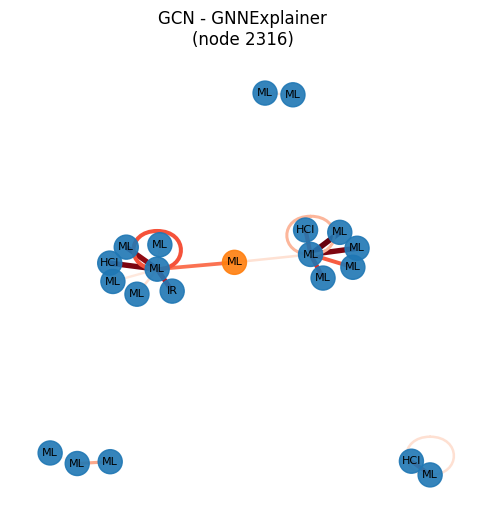

GCN - GNNExplainer metrics:
  predicted_class: 4 (ML)
  true_class: 4 (ML)
  is_correct: True
  full_prob: 0.9868
  masked_prob: 0.2462
  fidelity: 0.2495
  prob_drop: -0.7407
  sparsity: 0.0000
  edge_fraction_kept: 1.0000
  stability: 1.0000

Running PGExplainer for GCN...


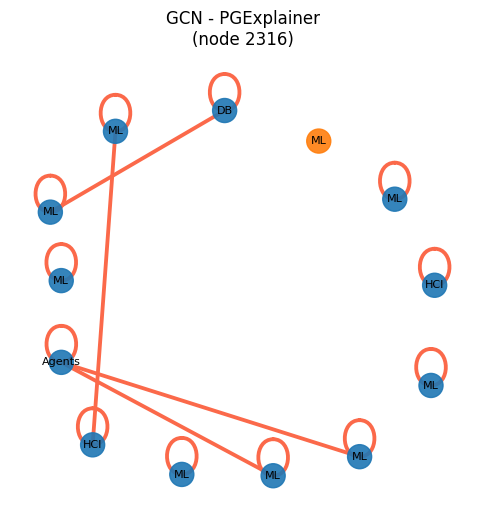

GCN - PGExplainer metrics:
  predicted_class: 4 (ML)
  true_class: 4 (ML)
  is_correct: True
  full_prob: 0.9868
  masked_prob: 0.1546
  fidelity: 0.1567
  prob_drop: -0.8323
  sparsity: 0.0000
  edge_fraction_kept: 1.0000
  stability: 1.0000

GCN explainer runs complete. Run the next cell for GraphSAGE.


In [12]:
test_nodes = test_mask.nonzero(as_tuple=False).view(-1)
if test_nodes.numel() == 0:
    raise ValueError("No test nodes available for explanation.")

# Choose sample node - modify this to select different nodes:
# Option 1: Pick by index (0 = first test node, 1 = second, etc.)
sample_idx = 4  # Change this number to select different test nodes

# Option 2: Uncomment to pick a random test node
# import random
# sample_idx = random.randint(0, test_nodes.numel() - 1)

# Option 3: Uncomment to use a specific node ID directly (if you know it)
# sample_node = 123  # Replace with specific node ID

sample_node = int(test_nodes[sample_idx].item())
print(f"Explaining node {sample_node} with label {int(labels[sample_node].item())} ({label_name_map[int(labels[sample_node].item())]})")

# Re-seed right before explainer runs so sampled training nodes stay fixed
seed_everything(SEED)

# Initialize results and run explainers for GCN only
results = []

print("\nRunning explainers for GCN only...")
results.append(explain_and_report(gcn_model, "GCN", "GNNExplainer", run_gnn_explainer, data, sample_node))
results.append(explain_and_report(gcn_model, "GCN", "PGExplainer", run_pg_explainer, data, sample_node))

print("\nGCN explainer runs complete. Run the next cell for GraphSAGE.")

Running explainers for GraphSAGE only...

Running GNNExplainer for GraphSAGE...


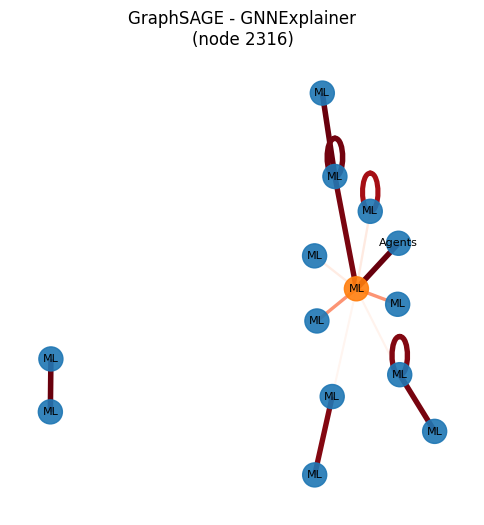

GraphSAGE - GNNExplainer metrics:
  predicted_class: 4 (ML)
  true_class: 4 (ML)
  is_correct: True
  full_prob: 0.9458
  masked_prob: 0.2051
  fidelity: 0.2168
  prob_drop: -0.7408
  sparsity: 0.0000
  edge_fraction_kept: 1.0000
  stability: 1.0000

Running PGExplainer for GraphSAGE...


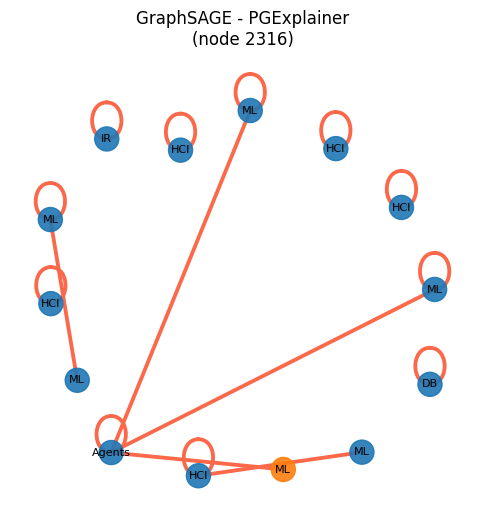

GraphSAGE - PGExplainer metrics:
  predicted_class: 4 (ML)
  true_class: 4 (ML)
  is_correct: True
  full_prob: 0.9458
  masked_prob: 0.1883
  fidelity: 0.1991
  prob_drop: -0.7575
  sparsity: 0.0000
  edge_fraction_kept: 1.0000
  stability: 1.0000

EXPLAINER COMPARISON
    Model    Explainer  is_correct  fidelity  prob_drop  sparsity  edge_fraction_kept  stability  full_prob  masked_prob
      GCN GNNExplainer        True  0.249460  -0.740667       0.0                 1.0   0.999973   0.986846     0.246179
      GCN  PGExplainer        True  0.156654  -0.832253       0.0                 1.0   0.999973   0.986846     0.154593
GraphSAGE GNNExplainer        True  0.216803  -0.740783       0.0                 1.0   0.999980   0.945844     0.205062
GraphSAGE  PGExplainer        True  0.199101  -0.757526       0.0                 1.0   0.999980   0.945844     0.188318

Metrics Guide:
  - fidelity: Lower is better (< 0.5 excellent, < 0.7 good)
  - prob_drop: More negative is better (shows pr

In [13]:
# Run explainers for GraphSAGE
print("Running explainers for GraphSAGE only...")
results.append(explain_and_report(graphsage_model, "GraphSAGE", "GNNExplainer", run_gnn_explainer, data, sample_node))
results.append(explain_and_report(graphsage_model, "GraphSAGE", "PGExplainer", run_pg_explainer, data, sample_node))

# Create comparison table after both model runs
comparison_df = compare_explainers(results)
print("\n" + "=" * 80)
print("EXPLAINER COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("\nMetrics Guide:")
print("  - fidelity: Lower is better (< 0.5 excellent, < 0.7 good)")
print("  - prob_drop: More negative is better (shows prediction degradation)")
print("  - sparsity: Higher is better (more compact explanation)")
print("  - stability: Higher is better (closer to 1.0 = more consistent)")

## Integrated Gradients Explanation
Use Integrated Gradients via Captum to compute gradient-based importance scores for node features, then derive edge importance from node attributions.

Running Integrated Gradients on node 2316 ...
(Computing gradient-based attributions via Captum directly for GCN...)

  → GCN


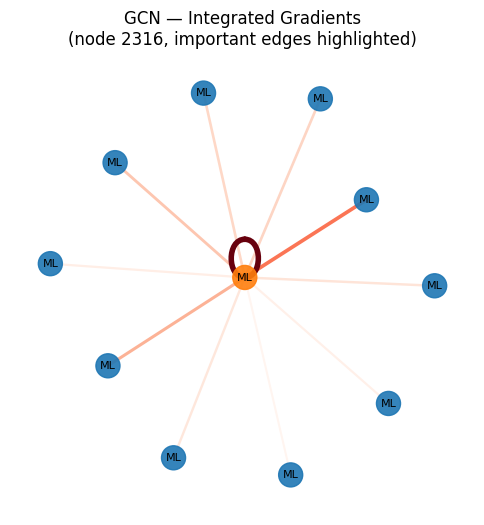

    Predicted: 4 (ML) | True: 4 (ML) | CORRECT
    Fidelity=0.9548  Prob_drop=-0.0446  Sparsity=0.0000  Stability=1.0000

GCN IG run complete. Run the next cell for GraphSAGE IG.


In [14]:
# ── Integrated Gradients explanation for GCN only ─────────────────────────────
print(f"Running Integrated Gradients on node {sample_node} ...")
print("(Computing gradient-based attributions via Captum directly for GCN...)\n")

ig_results = {}
model_obj, model_name = gcn_model, "GCN"
print(f"  → {model_name}")
_, ig_explanation, node_feat_mask_ig, edge_mask_ig, pred_class_ig = run_integrated_gradients(
    model_obj, sample_node, data
)
selection_ig = build_edge_selection(edge_mask_ig)

fig, ax = plt.subplots(figsize=(6, 6))
_plot_explanation(sample_node, data.edge_index, edge_mask_ig, selection_ig, ax)
ax.set_title(f"{model_name} — Integrated Gradients\n(node {sample_node}, important edges highlighted)")
plt.show()

ig_metrics = compute_explanation_metrics(
    model_obj, data, sample_node,
    node_feat_mask_ig, edge_mask_ig, selection_ig, pred_class_ig
)
ig_stability = estimate_ig_stability(model_obj, sample_node, data, runs=EXPLAINER_PARAMS_V2['stability_runs'])
ig_metrics["stability"] = ig_stability

ig_results[model_name] = {
    "explanation": ig_explanation,
    "edge_mask": edge_mask_ig,
    "node_feat_mask": node_feat_mask_ig,
    "pred_class": pred_class_ig,
    "model_obj": model_obj,
    "metrics": ig_metrics,
}
correct_str = "CORRECT" if ig_metrics["is_correct"] else "INCORRECT"
print(f"    Predicted: {ig_metrics['predicted_class']} ({label_name_map[ig_metrics['predicted_class']]}) | "
      f"True: {ig_metrics['true_class']} ({label_name_map[ig_metrics['true_class']]}) | {correct_str}")
print(f"    Fidelity={ig_metrics['fidelity']:.4f}  "
      f"Prob_drop={ig_metrics['prob_drop']:.4f}  "
      f"Sparsity={ig_metrics['sparsity']:.4f}  "
      f"Stability={ig_stability:.4f}")

print("\nGCN IG run complete. Run the next cell for GraphSAGE IG.")

Running Integrated Gradients on node 2316 for GraphSAGE ...

  → GraphSAGE


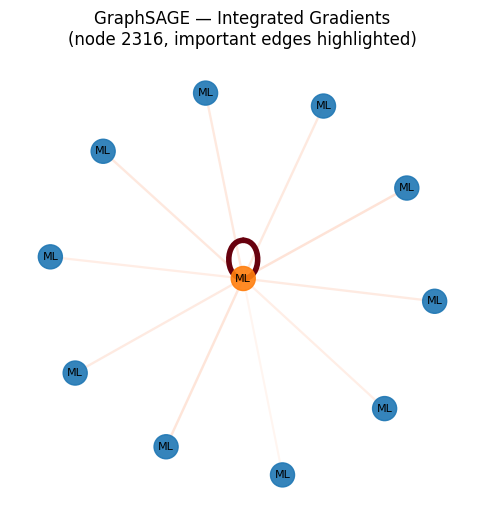

    Predicted: 4 (ML) | True: 4 (ML) | CORRECT
    Fidelity=1.0495  Prob_drop=0.0469  Sparsity=0.0000  Stability=1.0000


In [15]:
# ── Integrated Gradients explanation for GraphSAGE only ───────────────────────
print(f"Running Integrated Gradients on node {sample_node} for GraphSAGE ...\n")

model_obj, model_name = graphsage_model, "GraphSAGE"
print(f"  → {model_name}")
_, ig_explanation, node_feat_mask_ig, edge_mask_ig, pred_class_ig = run_integrated_gradients(
    model_obj, sample_node, data
)
selection_ig = build_edge_selection(edge_mask_ig)

fig, ax = plt.subplots(figsize=(6, 6))
_plot_explanation(sample_node, data.edge_index, edge_mask_ig, selection_ig, ax)
ax.set_title(f"{model_name} — Integrated Gradients\n(node {sample_node}, important edges highlighted)")
plt.show()

ig_metrics = compute_explanation_metrics(
    model_obj, data, sample_node,
    node_feat_mask_ig, edge_mask_ig, selection_ig, pred_class_ig
)
ig_stability = estimate_ig_stability(model_obj, sample_node, data, runs=EXPLAINER_PARAMS_V2['stability_runs'])
ig_metrics["stability"] = ig_stability

ig_results[model_name] = {
    "explanation": ig_explanation,
    "edge_mask": edge_mask_ig,
    "node_feat_mask": node_feat_mask_ig,
    "pred_class": pred_class_ig,
    "model_obj": model_obj,
    "metrics": ig_metrics,
}
correct_str = "CORRECT" if ig_metrics["is_correct"] else "INCORRECT"
print(f"    Predicted: {ig_metrics['predicted_class']} ({label_name_map[ig_metrics['predicted_class']]}) | "
      f"True: {ig_metrics['true_class']} ({label_name_map[ig_metrics['true_class']]}) | {correct_str}")
print(f"    Fidelity={ig_metrics['fidelity']:.4f}  "
      f"Prob_drop={ig_metrics['prob_drop']:.4f}  "
      f"Sparsity={ig_metrics['sparsity']:.4f}  "
      f"Stability={ig_stability:.4f}")

## Unified Explainer Comparison
Compare fidelity, sparsity, and stability metrics across all three explainers (GNNExplainer, PGExplainer, Integrated Gradients) for both models.

In [16]:
# ── Build unified comparison from cell 21 (results) and cell 23 (ig_results) ──
unified_rows = []

# GNNExplainer & PGExplainer metrics from `results` list
for r in results:
    m = r["metrics"]
    unified_rows.append({
        "Model":      r["model"],
        "Explainer":  r["explainer"],
        "Predicted":  m["predicted_class"],
        "True":       m["true_class"],
        "Correct":    m["is_correct"],
        "Fidelity":   m["fidelity"],
        "Prob Drop":  m["prob_drop"],
        "Sparsity":   m["sparsity"],
        "Edge Kept":  m["edge_fraction_kept"],
        "Stability":  m["stability"],
    })

# Integrated Gradients metrics from `ig_results` dict
for model_name, ig_data in ig_results.items():
    m = ig_data["metrics"]
    unified_rows.append({
        "Model":      model_name,
        "Explainer":  "IntegratedGradients",
        "Predicted":  m["predicted_class"],
        "True":       m["true_class"],
        "Correct":    m["is_correct"],
        "Fidelity":   m["fidelity"],
        "Prob Drop":  m["prob_drop"],
        "Sparsity":   m["sparsity"],
        "Edge Kept":  m["edge_fraction_kept"],
        "Stability":  m["stability"],
    })

unified_df = (
    pd.DataFrame(unified_rows)
    .sort_values(["Model", "Explainer"])
    .reset_index(drop=True)
)

print("=" * 90)
print("UNIFIED METRICS — GNNExplainer | PGExplainer | IntegratedGradients")
print("=" * 90)
print(unified_df.to_string(index=False))
print("\nMetrics Guide:")
print("  Fidelity  : Lower → removing explanation degrades prediction more (< 0.5 excellent)")
print("  Prob Drop : More negative → stronger prediction degradation when explanation removed")
print("  Sparsity  : Higher → more compact explanation (fewer edges kept)")
print("  Edge Kept : Fraction of edges retained in the explanation subgraph")
print("  Stability : Higher → explanation is consistent across runs (closer to 1.0)")
print("\nNote: IG edge importance is derived from node feature attributions via Captum.")

UNIFIED METRICS — GNNExplainer | PGExplainer | IntegratedGradients
    Model           Explainer  Predicted  True  Correct  Fidelity  Prob Drop  Sparsity  Edge Kept  Stability
      GCN        GNNExplainer          4     4     True  0.249460  -0.740667       0.0        1.0   0.999973
      GCN IntegratedGradients          4     4     True  0.954830  -0.044576       0.0        1.0   1.000000
      GCN         PGExplainer          4     4     True  0.156654  -0.832253       0.0        1.0   0.999973
GraphSAGE        GNNExplainer          4     4     True  0.216803  -0.740783       0.0        1.0   0.999980
GraphSAGE IntegratedGradients          4     4     True  1.049539   0.046856       0.0        1.0   1.000000
GraphSAGE         PGExplainer          4     4     True  0.199101  -0.757526       0.0        1.0   0.999980

Metrics Guide:
  Fidelity  : Lower → removing explanation degrades prediction more (< 0.5 excellent)
  Prob Drop : More negative → stronger prediction degradation when e

## Post-Training Embedding Snapshot
Repeat the projection with t-SNE after optimisation to show class separation.

/var/folders/cx/t80f8k7j2h1b0cnx64j7nxg00000gn/T/ipykernel_70115/2766157793.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(label_name_map))


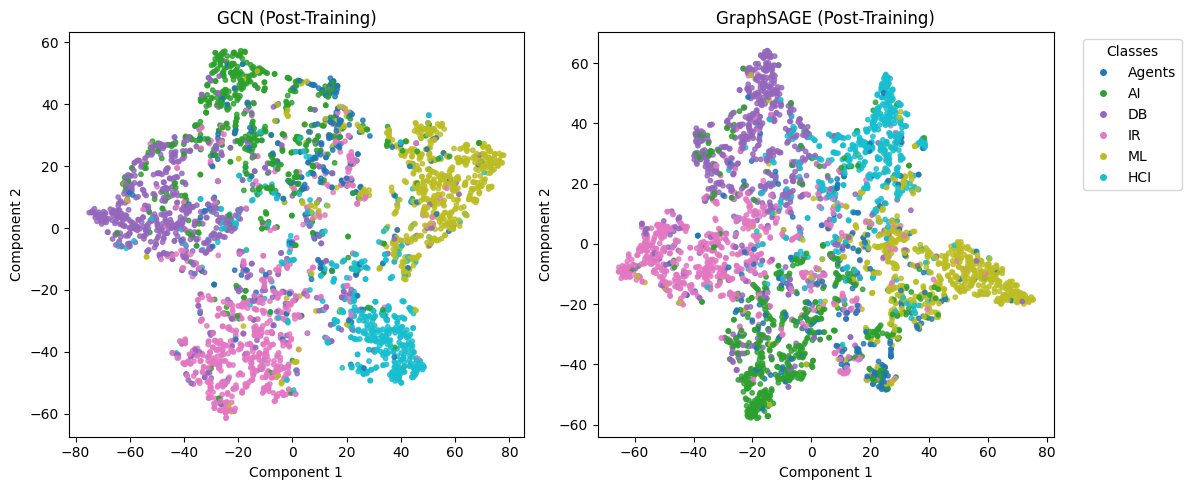

In [17]:
with torch.no_grad():
    gcn_model.eval()
    graphsage_model.eval()
    post_gcn_logits = gcn_model(data.x, data.edge_index)
    post_sage_logits = graphsage_model(data.x, data.edge_index)

post_gcn_coords = tsne_project(post_gcn_logits)
post_sage_coords = tsne_project(post_sage_logits)
plot_embeddings(post_gcn_coords, post_sage_coords, "(Post-Training)")

## Parameter Summary (Models and Explainers)

 > This cell documents the key parameter settings used in this notebook.

### Models
- **GCN**: `in_channels=dataset.num_features`, `hidden_channels=64`, `num_layers=2`, `out_channels=dataset.num_classes`, `dropout=0.5`
- **GraphSAGE**: `in_channels=dataset.num_features`, `hidden_channels=64`, `num_layers=2`, `out_channels=dataset.num_classes`, `dropout=0.5`

> Both models are instantiated from PyTorch Geometric built-in classes (`GCN`, `GraphSAGE`).

> Note: `data.edge_index` is updated with self-loops before training/explaining.

### Training
- **Loss**: `CrossEntropyLoss()`
- **GCN optimizer**: `Adam(lr=0.005, weight_decay=5e-3)`
- **GraphSAGE optimizer**: `Adam(lr=0.005, weight_decay=5e-4)`
- **Schedulers**: `ReduceLROnPlateau(mode='min', factor=0.7, patience=30, min_lr=3e-4)` for both models
- **Gradient clipping**: `clip_grad_norm_(max_norm=2.0)` for both models
- **GCN epochs**: up to `1000` with early stopping
- **GCN early stopping patience**: `100`
- **GraphSAGE epochs**: up to `1000` with early stopping
- **GraphSAGE early stopping patience**: `100`
- **Best-checkpoint restore**: best validation-loss weights are reloaded after training for both models
- **Global seed**: `SEED=67` via `seed_everything(SEED)` (Python, NumPy, PyTorch, CUDA + deterministic backend flags)

> Masks used: `train_mask`, `val_mask`, `test_mask`.

> Sample explanation node currently selected with `sample_idx = 4` from test nodes.

### Explainers
- **GNNExplainer**: `epochs=350`
  - `explanation_type='phenomenon'`
  - `mode='multiclass_classification'`, `task_level='node'`, `return_type='raw'`
  - `node_mask_type='attributes'`, `edge_mask_type='object'`
- **Stability for GNNExplainer**: `epochs=240` per run with `runs=9`
- **PGExplainer**: `epochs=40`, `lr=0.0025`, train subset size `140` nodes per epoch
  - `explanation_type='phenomenon'`
  - `mode='multiclass_classification'`, `task_level='node'`, `return_type='raw'`
  - `node_mask_type=None`, `edge_mask_type='object'`
- **Integrated Gradients (Captum)**: `n_steps=192`, `internal_batch_size=1`
  - Edge importance is derived from node attributions via `_derive_edge_mask_from_node_mask`
  - Stability estimated with `runs=9`
- **Edge selection for visualization/metrics**: `quantile=0.94`, minimum `12` edges kept

> Comparison metrics reported: `fidelity`, `prob_drop`, `sparsity`, `edge_fraction_kept`, `stability`.

> Active explainer profile: tuned_v4 (sourced from mainCorav4).